In [5]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import newton
import matplotlib.pyplot as plt

# Modified Newtonian Dynamics

In [39]:
G = 1.0          # Normalized units: GM_* = 1, h = 1
e = 0.6

# For demonstration, we can temporarily increase a0 to see clear rosette
# a0_demo = a0 * 1e6   # Uncomment for strong visible precession
a0 = 1
def mond_acceleration(r, a0):
    if r < 1e-10:
        r = 1e-10
    a_N = G / r**2
    # Exact expression from notes Eq.(56)
    a_MOND = 0.5 * (a_N + np.sqrt(a_N**2 + 4 * a_N * a0))
    return a_MOND

def mond_orbit_numerical(a, e, omega_deg, Omega_deg, inc_deg, M_BH, 
                         t_span, n_points=30000, a0_factor=1.0):
    a0_used = a0 * a0_factor
    omega = np.radians(omega_deg)
    Omega = np.radians(Omega_deg)
    inc = np.radians(inc_deg)
    
    r_peri = a * (1 - e)
    v_peri = np.sqrt(G * M_BH * (1 + e) / (a * (1 - e)))  # Newtonian approx
    
    y0 = [r_peri, 0.0, 0.0, v_peri]
    
    def deriv(t, y):
        x, y_pos, vx, vy = y
        r = np.hypot(x, y_pos)
        g = mond_acceleration(r, a0_used)
        ax = -g * (x / r)
        ay = -g * (y_pos / r)
        return [vx, vy, ax, ay]
    
    sol = solve_ivp(deriv, t_span, y0, method='DOP853', 
                    rtol=1e-11, atol=1e-13, dense_output=True)
    
    times = np.linspace(t_span[0], t_span[1], n_points)
    orbit = sol.sol(times)
    x_orb, y_orb = orbit[0], orbit[1]
    
    # Sky projection (identical to Kepler function)
    def R_z(theta):
        c, s = np.cos(theta), np.sin(theta)
        return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])
    def R_x(theta):
        c, s = np.cos(theta), np.sin(theta)
        return np.array([[1, 0, 0], [0, c, -s], [0, s, c]])
    
    R = R_z(-Omega) @ R_x(-inc) @ R_z(-omega)
    
    x_sky = np.zeros_like(times)
    y_sky = np.zeros_like(times)
    for i in range(len(times)):
        pos = np.array([x_orb[i], y_orb[i], 0.0])
        r_sky = R @ pos
        x_sky[i], y_sky[i] = r_sky[0], r_sky[1]
    
    return x_sky, y_sky, times

In [ ]:
M_BH = 1
a = 1000.0
e = 0.88
inc = 135
omega = 65
Omega = 225

P = 2 * np.pi * np.sqrt(a**3 / (G * M_BH))

# Keplerian reference
#x_kepler, y_kepler = kepler_orbit(a, e, omega, Omega, inc, M_BH, 
#                                  np.linspace(0, 4*P, 10000))

# MOND - use a0_factor > 1 for visible precession in reasonable time
x_mond, y_mond, _ = mond_orbit_numerical(a, e, omega, Omega, inc, M_BH, 
                                         t_span=[0, 12*P], 
                                         a0_factor=5e5)   # Tune this for visibility

plt.figure(figsize=(10, 10))
#plt.plot(y_kepler, x_kepler, 'b-', lw=2, label='Keplerian (closed ellipse)')
plt.plot(y_mond, y_mond, 'r--', lw=1.8, label='MOND (precessing rosette)')
plt.scatter([0], [0], c='k', marker='*', s=400, label='Sgr A*')
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.title("Kepler vs MOND Orbit\n(Precession visible with enhanced a0)")
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

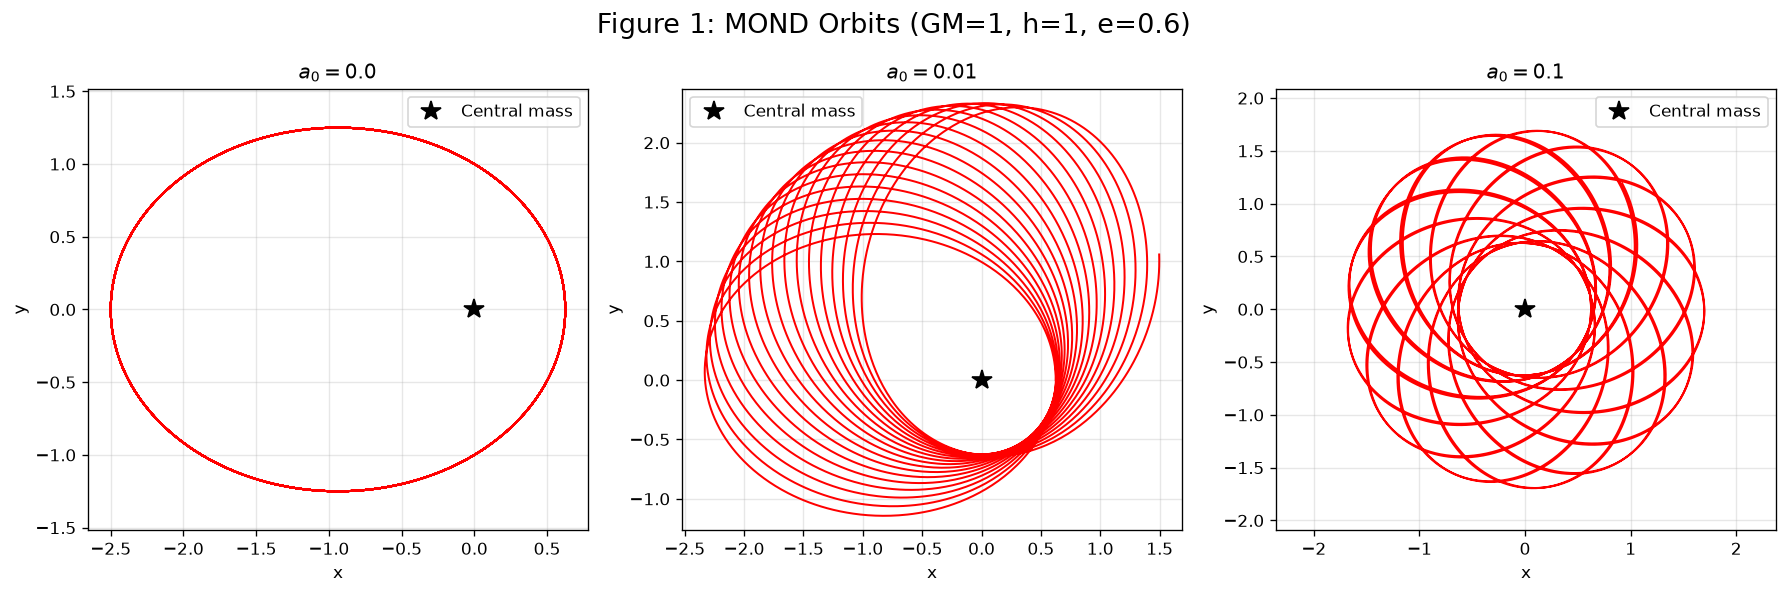

In [34]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

G = 1.0          # Normalized units: GM_* = 1, h = 1
e = 0.6
a0_values = [0.0, 0.01, 0.1]

def mond_acc_mond_notes(r, a0):
    """Exact MOND acceleration from notes Eq.(56)"""
    if r < 1e-12:
        r = 1e-12
    a_N = G / r**2
    return 0.5 * (a_N + np.sqrt(a_N**2 + 4 * a_N * a0))

def plot_mond_figure1():
    fig, axs = plt.subplots(1, 3, figsize=(15, 5), dpi=120)
    fig.suptitle('Figure 1: MOND Orbits (GM=1, h=1, e=0.6)', fontsize=16)
    
    for idx, a0 in enumerate(a0_values):
        # Initial conditions at pericenter
        r_peri = 1 / (1 + e)          # p = 1
        v_peri = np.sqrt(G * (1 + e) / r_peri)
        
        y0 = [r_peri, 0.0, 0.0, v_peri]
        
        def deriv(t, y):
            x, y_pos, vx, vy = y
            r = np.hypot(x, y_pos)
            g = mond_acc_mond_notes(r, a0)
            ax = -g * (x / r)
            ay = -g * (y_pos / r)
            return [vx, vy, ax, ay]
        
        # Integrate over many periods
        sol = solve_ivp(deriv, [0, 200], y0, method='DOP853',
                        rtol=1e-10, atol=1e-12, dense_output=True)
        
        t = np.linspace(0, 200, 8000)
        orbit = sol.sol(t)
        x, y = orbit[0], orbit[1]
        
        axs[idx].plot(x, y, 'r-', lw=1.2)
        axs[idx].plot(0, 0, 'k*', ms=12, label='Central mass')
        axs[idx].set_title(f'$a_0 = {a0}$')
        axs[idx].set_xlabel('x')
        axs[idx].set_ylabel('y')
        axs[idx].axis('equal')
        axs[idx].grid(True, alpha=0.3)
        axs[idx].legend()
    
    plt.tight_layout()
    plt.show()

# Run the figure
plot_mond_figure1()